In [1]:
import sys

print(sys.executable)

/usr/local/Caskroom/miniconda/base/envs/fakebusters-clean/bin/python


In [2]:
import os
import sys

os.chdir("/Users/karima/Ironhack-challenges/fake-news-nlp-classification")
sys.path.append(os.getcwd())

print(os.getcwd())

/Users/karima/Ironhack-challenges/fake-news-nlp-classification


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from src.data_loader import load_data, prepare_features_and_labels, split_data
from src.preprocessing import preprocess_data
from src.feature_extraction import create_tfidf_features
from src.evaluator import evaluate_model, save_confusion_matrix, save_metrics_plot
from src.experiment_tracker import save_experiment_result
from src.model_manager import save_model, save_vectorizer
from src.config import MODELS_DIR

In [4]:
# Class constants
MODEL_ID = "exp_07"
MODEL_NAME = "Random Forest + TF-IDF"
FEATURES = "TF-IDF"
PREPROCESSING = "Lowercase + HTML removal + stopword removal + lemmatization"
ALGORITHM = "Random Forest"
NOTES = "Random Forest model using TF-IDF features."
MODEL_PATH = MODELS_DIR / "tfidf_random_forest.pkl"

In [5]:
# Load the dataset
data = load_data()

In [6]:
# Extract features X and labels y
X, y = prepare_features_and_labels(data)

In [7]:
# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = split_data(X, y)

In [ ]:
# Data cleaning, tokenization and lemmatization
X_train_clean = preprocess_data(X_train)
X_test_clean = preprocess_data(X_test)

In [ ]:
# Create TF-IDF features
X_train_features, X_test_features, vectorizer = create_tfidf_features(
    X_train_clean,
    X_test_clean
)

In [ ]:
# Train the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_features, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [ ]:
# Evaluate the model
metrics, predictions = evaluate_model(
    model,
    X_test_features,
    y_test
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3989
           1       1.00      1.00      1.00      4000

    accuracy                           1.00      7989
   macro avg       1.00      1.00      1.00      7989
weighted avg       1.00      1.00      1.00      7989



In [ ]:
# Save the model and vectorizer
model_path = save_model(
    model,
    "tfidf_random_forest.pkl"
)

vectorizer_path = save_vectorizer(
    vectorizer,
    "tfidf_random_forest_vectorizer.pkl"
)

Model saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/tfidf_random_forest.pkl
Vectorizer saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/tfidf_random_forest_vectorizer.pkl


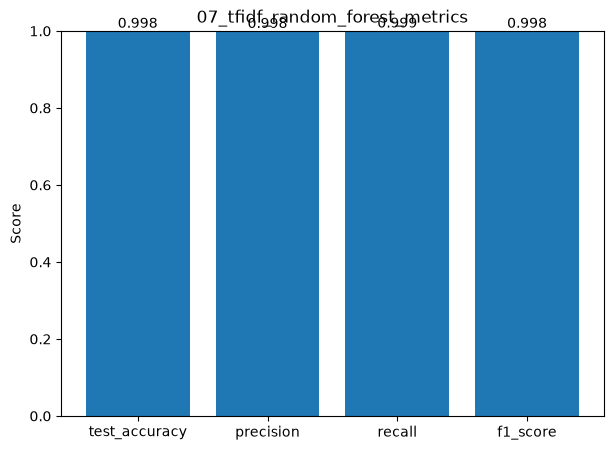

In [ ]:
# Save and show metrics plot
metrics_plot_path = save_metrics_plot(
    metrics,
    "07_tfidf_random_forest_metrics"
)

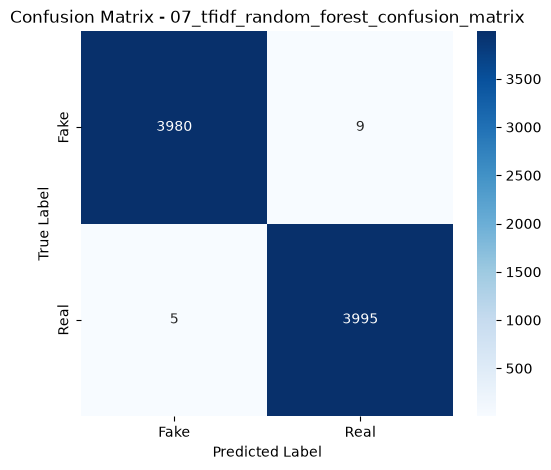

In [ ]:
# Save and show confusion matrix
confusion_matrix_path = save_confusion_matrix(
    y_test,
    predictions,
    "07_tfidf_random_forest_confusion_matrix"
)

In [ ]:
# Train accuracy
train_prediction = model.predict(X_train_features)

train_accuracy = accuracy_score(
    y_train,
    train_prediction
)

In [ ]:
# Save experiment result
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "features": FEATURES,
    "preprocessing": PREPROCESSING,
    "algorithm": ALGORITHM,
    "train_accuracy": train_accuracy,
    "test_accuracy": metrics["test_accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "notes": NOTES,
    "model_path": MODEL_PATH,
}

tracking = save_experiment_result(**experiment)

tracking.tail()

,model_id,model_name,features,preprocessing,algorithm,train_accuracy,test_accuracy,precision,recall,f1_score,notes,model_path
17,exp_09,Logistic Regression + TF-IDF + Bigrams,TF-IDF + n-grams (unigrams and bigrams),Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.992802,0.987232,0.984826,0.98975,0.987282,Baseline Logistic Regression model using TF-ID...,/Users/karima/Ironhack-challenges/fake-news-nl...
18,exp_10,Naive Bayes + TF-IDF + Bigrams,TF-IDF + n-grams (unigrams and bigrams),Lowercase + HTML removal + stopword removal + ...,Multinomial Naive Bayes,0.952305,0.945675,0.947990,0.94325,0.945614,Multinomial Naive Bayes model using TF-IDF uni...,/Users/karima/Ironhack-challenges/fake-news-nl...
19,exp_11,Random Forest + TF-IDF + Bigrams,TF-IDF + n-grams (unigrams and bigrams),Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.997497,0.997749,0.99725,0.997499,Random Forest model using TF-IDF unigram and b...,/Users/karima/Ironhack-challenges/fake-news-nl...
20,exp_12,SVM + TF-IDF + Bigrams,TF-IDF + n-grams (unigrams and bigrams),Lowercase + HTML removal + stopword removal + ...,Linear SVM,0.999437,0.994367,0.994499,0.99425,0.994374,Linear SVM model using TF-IDF unigram and bigr...,/Users/karima/Ironhack-challenges/fake-news-nl...
21,exp_07,Random Forest + TF-IDF,TF-IDF,Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.998248,0.997752,0.99875,0.998251,Random Forest model using TF-IDF features.,/Users/karima/Ironhack-challenges/fake-news-nl...
